In [3]:
from pathlib import Path
import pandas as pd

files = sorted(Path('../data/raw').glob('*.csv'))
for f in files:
    df = pd.read_csv(f, low_memory=False)
    df['acq_date'] = pd.to_datetime(df['acq_date'])
    print('FILE:',f.name)
    print('  size MB:',round(f.stat().st_size / 1e6,1))
    print('  rows,columns:', df.shape)
    print('  first date:', df['acq_date'].min().date(), '| last date:',df['acq_date'].max().date())
    for col in ['instruments','satelite']:
        if col in df.columns:
            print(' ', col + ':', df[col].unique())
    print('  confidence examples:', df['confidence'].unique()[:6])  
    print('  columns:', df.columns.tolist())

FILE: fire_archive_M-C61_817230.csv
  size MB: 138.5
  rows,columns: (1721754, 15)
  first date: 2000-11-02 | last date: 2026-06-30
  confidence examples: [59 86 70 49 38 42]
  columns: ['latitude', 'longitude', 'brightness', 'scan', 'track', 'acq_date', 'acq_time', 'satellite', 'instrument', 'confidence', 'version', 'bright_t31', 'frp', 'daynight', 'type']
FILE: fire_archive_SV-C2_817231.csv
  size MB: 240.5
  rows,columns: (2924041, 15)
  first date: 2012-01-20 | last date: 2026-06-30
  confidence examples: <ArrowStringArray>
['n', 'h', 'l']
Length: 3, dtype: str
  columns: ['latitude', 'longitude', 'brightness', 'scan', 'track', 'acq_date', 'acq_time', 'satellite', 'instrument', 'confidence', 'version', 'bright_t31', 'frp', 'daynight', 'type']
FILE: fire_nrt_M-C61_817230.csv
  size MB: 1.0
  rows,columns: (11851, 14)
  first date: 2026-07-01 | last date: 2026-10-04
  confidence examples: [40 62 64 92 72 55]
  columns: ['latitude', 'longitude', 'brightness', 'scan', 'track', 'acq_dat

In [4]:
from pathlib import Path
import pandas as pd

raw = Path('../data/raw')
cols = ['latitude','longitude','acq_date','acq_time','satellite','instrument','confidence','frp','daynight']

def load_sensor(archive_name,nrt_name):
    parts = []
    for name,source in [(archive_name,'archive'),(nrt_name, 'nrt')]:
        df = pd.read_csv(raw / name, usecols = cols, low_memory = False)
        df['acq_date'] = pd.to_datetime(df['acq_date'])
        df['source'] = source
        parts.append(df)

    out = pd.concat(parts, ignore_index=True)
    return out.sort_values('acq_date').reset_index(drop = True)


modis = load_sensor('fire_archive_M-C61_817230.csv', 'fire_nrt_M-C61_817230.csv')
viirs = load_sensor('fire_archive_SV-C2_817231.csv', 'fire_nrt_SV-C2_817231.csv')

print('MODIS', modis.shape, modis['acq_date'].min().date(), modis['acq_date'].max().date())
print('VIIRS', viirs.shape, viirs['acq_date'].min().date(), viirs['acq_date'].max().date())


    

MODIS (1733605, 10) 2000-11-02 2026-10-04
VIIRS (2968081, 10) 2012-01-20 2026-10-04


           modis     viirs  viirs_per_modis
acq_date                                   
2000        7188       NaN              NaN
2001       31841       NaN              NaN
2002       60367       NaN              NaN
2003      117096       NaN              NaN
2004       99969       NaN              NaN
2005       71192       NaN              NaN
2006       84658       NaN              NaN
2007       78067       NaN              NaN
2008      104702       NaN              NaN
2009       82019       NaN              NaN
2010       62712       NaN              NaN
2011       76433       NaN              NaN
2012       61885  189787.0             3.07
2013       66553  237553.0             3.57
2014       36817  126346.0             3.43
2015       45140  151071.0             3.35
2016       55414  181421.0             3.27
2017       60301  201664.0             3.34
2018       55410  184924.0             3.34
2019       50388  161688.0             3.21
2020      124103  448313.0      

<Axes: xlabel='acq_date'>

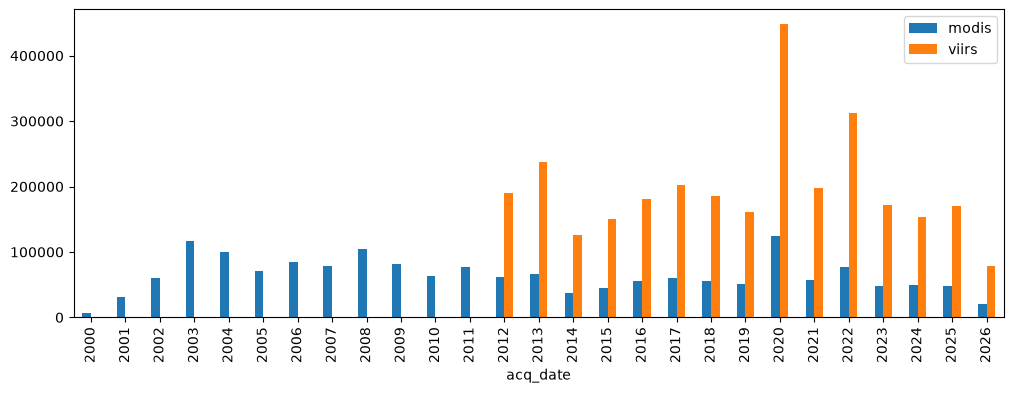

In [5]:
yearly = pd.DataFrame({
    'modis': modis.groupby(modis['acq_date'].dt.year).size(),
    'viirs': viirs.groupby(viirs['acq_date'].dt.year).size(),
})
yearly['viirs_per_modis'] = (yearly['viirs'] / yearly['modis']).round(2)
print(yearly)
yearly[['modis','viirs']].plot(kind = 'bar',figsize = (12,4))

In [6]:
pip install pyarrow

Note: you may need to restart the kernel to use updated packages.


In [7]:
from pathlib import Path

In [8]:
Path('../data/processed').mkdir(parents=True, exist_ok = True)
modis.to_parquet('../data/processed/modis_argentina.parquet')
viirs.to_parquet('../data/processed/viirs_argentina.parquet')

In [9]:
by_sat = modis.groupby([modis['acq_date'].dt.year,'satellite']).size().unstack()
print(by_sat)

satellite     Aqua    Terra
acq_date                   
2000           NaN   7188.0
2001           NaN  31841.0
2002       33680.0  26687.0
2003       76481.0  40615.0
2004       63862.0  36107.0
2005       44053.0  27139.0
2006       53908.0  30750.0
2007       50538.0  27529.0
2008       67621.0  37081.0
2009       52140.0  29879.0
2010       38962.0  23750.0
2011       47491.0  28942.0
2012       39240.0  22645.0
2013       41628.0  24925.0
2014       21964.0  14853.0
2015       28724.0  16416.0
2016       35889.0  19525.0
2017       37433.0  22868.0
2018       35107.0  20303.0
2019       32071.0  18317.0
2020       80826.0  43277.0
2021       36150.0  20726.0
2022       49629.0  27893.0
2023       29466.0  18445.0
2024       33576.0  16267.0
2025       33334.0  14787.0
2026       15057.0   6020.0


In [10]:
#Cleaning the data and then rechecking the ratio
import numpy as np

#we are keeping only the reasonable confidence score datas
modis_clean = modis[modis['confidence'] >= 30].copy()
viirs_clean = viirs[viirs['confidence'].isin(['n','h'])].copy()

print('MODIS', len(modis), '->', len(modis_clean))
print('viirs', len(viirs), '->', len(viirs_clean))

MODIS 1733605 -> 1650682
viirs 2968081 -> 2710148


In [11]:
#we are counting footprints here instead of the raw points

def dedupe_footprints(df):
    df = df.copy()
    df['k_lat'] = np.floor(df['latitude']/0.01)
    df['k_lon'] = np.floor(df['longitude']/0.01)
    return df.drop_duplicates(['acq_date','k_lat','k_lon'])

'''
a VIIRS pixel is smaller, so one burning area can produce several VIIRS points.
We snap every detection onto a grid of roughly 1 km squares (0.01 degrees)
and keep one detection per square per day.
Now both sensors answer the same question: how many 1 km patches burned on this day?

'''
modis_fp = dedupe_footprints(modis_clean)
viirs_fp = dedupe_footprints(viirs_clean)

print('MODIS', len(modis_clean), '->', len(modis_fp))
print('VIIRS', len(viirs_clean), '->', len(viirs_fp))

MODIS 1650682 -> 1512387
VIIRS 2710148 -> 1557123


In [12]:
import numpy as np
import pandas as pd

demo = pd.DataFrame({
    'acq_date': ['2020-01-05'] * 4 + ['2020-01-06'],
    'latitude':  [-31.2345, -31.2361, -31.2399, -31.2501, -31.2345],
    'longitude': [-64.1001, -64.1020, -64.1005, -64.1002, -64.1001],
})
print('raw rows:', len(demo))

demo['k_lat'] = np.floor(demo['latitude'] / 0.01)
demo['k_lon'] = np.floor(demo['longitude'] / 0.01)
print(demo)

footprints = demo.drop_duplicates(['acq_date', 'k_lat', 'k_lon'])
print('footprint rows:', len(footprints))
print(footprints)

raw rows: 5
     acq_date  latitude  longitude   k_lat   k_lon
0  2020-01-05  -31.2345   -64.1001 -3124.0 -6411.0
1  2020-01-05  -31.2361   -64.1020 -3124.0 -6411.0
2  2020-01-05  -31.2399   -64.1005 -3124.0 -6411.0
3  2020-01-05  -31.2501   -64.1002 -3126.0 -6411.0
4  2020-01-06  -31.2345   -64.1001 -3124.0 -6411.0
footprint rows: 3
     acq_date  latitude  longitude   k_lat   k_lon
0  2020-01-05  -31.2345   -64.1001 -3124.0 -6411.0
3  2020-01-05  -31.2501   -64.1002 -3126.0 -6411.0
4  2020-01-06  -31.2345   -64.1001 -3124.0 -6411.0


In [13]:
yearly2 = pd.DataFrame({
    'modis': modis_fp.groupby(modis_fp['acq_date'].dt.year).size(),
    'viirs': viirs_fp.groupby(viirs_fp['acq_date'].dt.year).size(),
})

yearly2['viirs_per_modis'] = (yearly2['viirs']/yearly2['modis']).round(2)
print(yearly2.loc[2012:2026])

           modis     viirs  viirs_per_modis
acq_date                                   
2012       54242  105413.0             1.94
2013       57982  120723.0             2.08
2014       32069   68361.0             2.13
2015       39890   86680.0             2.17
2016       48607   96145.0             1.98
2017       52760  102766.0             1.95
2018       48623  101425.0             2.09
2019       44348   90067.0             2.03
2020      106165  225852.0             2.13
2021       49728  107637.0             2.16
2022       65362  144651.0             2.21
2023       41354   86133.0             2.08
2024       44266   83979.0             1.90
2025       42625   92543.0             2.17
2026       18896   44748.0             2.37


In [14]:
from pathlib import Path
print([p.name for p in Path('../data/processed').glob('*')])

['modis_argentina.parquet', 'modis_argentina_fp.parquet', 'monthly_overlap_argentina.csv', 'viirs_argentina.parquet', 'viirs_argentina_fp.parquet']


In [15]:
print(len(modis_fp), len(viirs_fp))

1512387 1557123


In [16]:
modis_fp.to_parquet('../data/processed/modis_argentina_fp.parquet')
viirs_fp.to_parquet('../data/processed/viirs_argentina_fp.parquet')

In [17]:
from pathlib import Path
print([p.name for p in Path('../data/processed').glob('*')])

['modis_argentina.parquet', 'modis_argentina_fp.parquet', 'monthly_overlap_argentina.csv', 'viirs_argentina.parquet', 'viirs_argentina_fp.parquet']


In [18]:
import time

t = time.time()
a = pd.read_csv('../data/raw/fire_archive_SV-C2_817231.csv', low_memory=False)
print('CSV:    ', round(time.time() - t, 1), 'seconds')

t = time.time()
b = pd.read_parquet('../data/processed/viirs_argentina_fp.parquet')
print('Parquet:', round(time.time() - t, 1), 'seconds')

CSV:     4.9 seconds
Parquet: 0.9 seconds


In [19]:
import pandas as pd
import numpy as np

#we are trying to see if we can find some relation by comparing them according to months instead of years
modis_fp = pd.read_parquet('../data/processed/modis_argentina_fp.parquet')
viirs_fp = pd.read_parquet('../data/processed/viirs_argentina_fp.parquet')

m = modis_fp.groupby(modis_fp['acq_date'].dt.to_period('M')).size()
v = viirs_fp.groupby(viirs_fp['acq_date'].dt.to_period('M')).size()

print(m.tail(3))
print(v.tail(3))

acq_date
2026-08    2057
2026-09    6447
2026-10     219
Freq: M, dtype: int64
acq_date
2026-08     6001
2026-09    14985
2026-10      811
Freq: M, dtype: int64


In [20]:
#coomparing square fire detection for both the sensors in 2 columns side by side
both = pd.concat([m,v], axis=1, keys=['modis','viirs']).dropna()
both = both.loc['2012-02':'2026-06']
print(both.shape)
print(both.head)

(172, 2)
<bound method NDFrame.head of           modis   viirs
acq_date               
2012-02    2616  6151.0
2012-03    3356  7383.0
2012-04    1054  3101.0
2012-05    1663  4489.0
2012-06    3025  7036.0
...         ...     ...
2026-01    2498  5552.0
2026-02    1901  4695.0
2026-03    1470  3644.0
2026-04     682  1808.0
2026-06     593  2691.0

[172 rows x 2 columns]>


In [21]:
k = both['modis'].sum() / both['viirs'].sum()
r = both['modis'].corr(both['viirs'])
both['viirs_scaled'] = both['viirs'] * k
rel_gap = ((both['viirs_scaled'] - both['modis']).abs()/ both['modis']).median()

print('Scaling factor k:', round(k, 3))
print('Correlation r:   ', round(r, 3))
print('Typical monthly gap after scaling:', round(rel_gap * 100, 1), '%')

Scaling factor k: 0.478
Correlation r:    0.99
Typical monthly gap after scaling: 13.7 %


In [22]:
#seeing if the ratio is steady over time
both['ratio'] = both['viirs'] / both['modis']
by_year = both['ratio'].groupby(both.index.year).median()
print(by_year.round(2))

acq_date
2012    2.16
2013    2.27
2014    2.28
2015    2.17
2016    2.11
2017    1.99
2018    2.30
2019    2.10
2020    2.12
2021    2.31
2022    2.44
2023    2.31
2024    2.08
2025    2.28
2026    2.48
Name: ratio, dtype: float64


<Axes: title={'center': 'Each dot = one month'}, xlabel='viirs', ylabel='modis'>

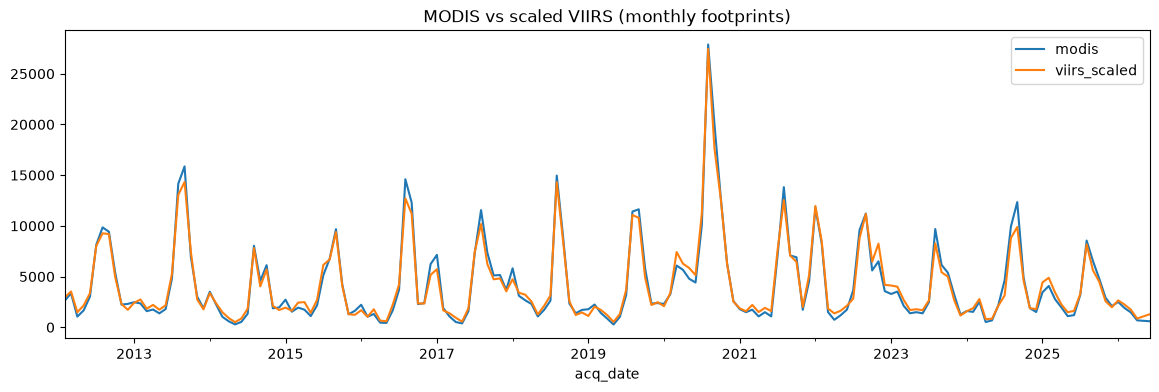

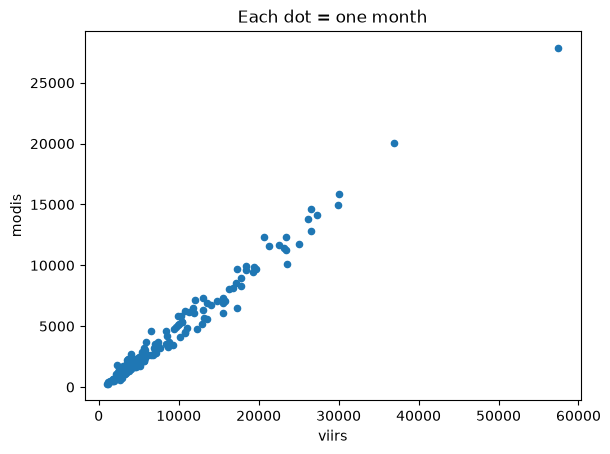

In [23]:
both[['modis','viirs_scaled']].plot(figsize=(14,4), title ='MODIS vs scaled VIIRS (monthly footprints)' )
both.plot.scatter(x='viirs', y='modis',title = 'Each dot = one month')

In [24]:
both.to_csv('../data/processed/monthly_overlap_argentina.csv')

In [25]:
both['ratio'] = both['viirs'] / both['modis']
busy = both['viirs'] >= both['viirs'].quantile(0.75)

print('ratio in normal/quite months:', round(both.loc[~busy,'ratio'].median(),2))
print('ratio in the busiest 25%:    ', round(both.loc[busy,'ratio'].median(),2))

by_year = both['ratio'].groupby(both.index.year).median()
print(by_year.round(2))

ratio in normal/quite months: 2.38
ratio in the busiest 25%:     2.03
acq_date
2012    2.16
2013    2.27
2014    2.28
2015    2.17
2016    2.11
2017    1.99
2018    2.30
2019    2.10
2020    2.12
2021    2.31
2022    2.44
2023    2.31
2024    2.08
2025    2.28
2026    2.48
Name: ratio, dtype: float64


(1064412, 5)
acq_date
2003    102957.0
2004     87500.0
2005     62455.0
2006     73918.0
2007     68543.0
2008     90632.0
2009     70343.0
2010     54642.0
2011     66765.0
2012     54115.0
2013     57706.0
2014     32677.0
2015     41433.0
2016     45957.0
2017     49122.0
2018     48481.0
2019     43052.0
2020    107957.0
2021     51450.0
2022     69143.0
2023     41172.0
2024     40142.0
2025     44236.0
2026     21390.0
Name: count_harmonized, dtype: float64


<Axes: title={'center': 'Harmonized fire footprints per year, Argentina'}, xlabel='acq_date'>

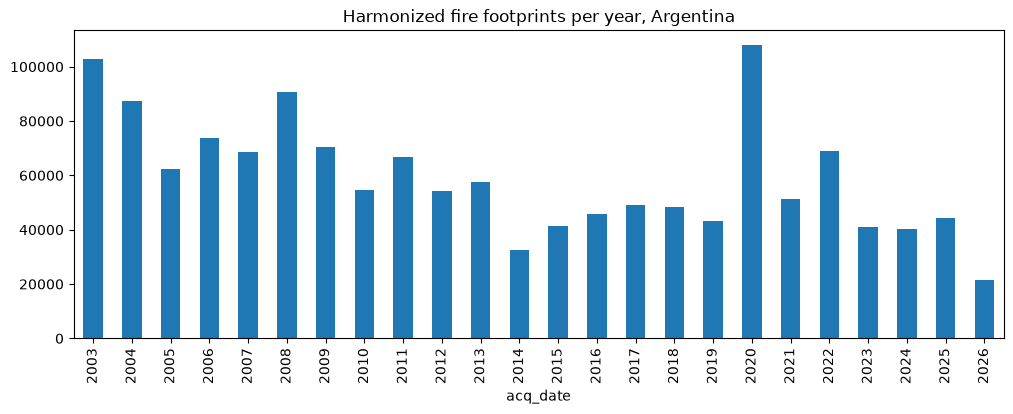

In [27]:
#building the table used by calendar

def to_daily_grid(df,name,step=0.25):  #25km per square for the grid; so step = 0.25
    df = df.copy()
    df['cell_lat'] = np.floor(df['latitude'] / step ) * step
    df['cell_lon'] = np.floor(df['longitude'] / step) * step
    return(df.groupby(['acq_date','cell_lat','cell_lon']).size().rename(name).reset_index())

gm = to_daily_grid(modis_fp, 'count_modis')
gv = to_daily_grid(viirs_fp, 'count_viirs')

grid = gm.merge(gv, on=['acq_date','cell_lat','cell_lon'], how = 'outer').fillna(0)
grid[['count_modis','count_viirs']] = grid[['count_modis','count_viirs']].astype(int)
print(grid.shape)
grid.head()

k = 0.478
start = pd.Timestamp('2003-01-01')
switch = pd.Timestamp('2012-02-01')

grid = grid[grid['acq_date'] >= start].copy()
use_modis = grid['acq_date'] < switch #use the modis values till 2012

grid['count_harmonized'] = np.where(use_modis, grid['count_modis'], grid['count_viirs'] * k)
grid['source'] = np.where(use_modis, 'MODIS measured', 'VIIRS scaled')

yearly_h = grid.groupby(grid['acq_date'].dt.year)['count_harmonized'].sum()
print(yearly_h.round(0))
yearly_h.plot(kind = 'bar', figsize=(12,4), title = 'Harmonized fire footprints per year, Argentina')

In [28]:
grid.to_parquet('../data/processed/daily_grid_argentina.parquet')

In [29]:
#Turning the grid into one number per day for argentina
daily = grid.groupby('acq_date')['count_harmonized'].sum()
daily = daily.asfreq('D', fill_value=0) #taking every calendar day into count
print(daily.tail())

acq_date
2026-09-30     40.630
2026-10-01    125.236
2026-10-02    155.828
2026-10-03     87.952
2026-10-04     18.642
Freq: D, Name: count_harmonized, dtype: float64


In [30]:
#Checking how they differ on a daily, weekly and monthly basis
d = grid.groupby('acq_date')[['count_modis', 'count_viirs']].sum()
d = d.asfreq('D', fill_value=0).loc['2012-02-01':'2026-06-30']
d['viirs_scaled'] = d['count_viirs'] * 0.478

def score(df, label):
    r = df['count_modis'].corr(df['viirs_scaled'])
    active = df[df['count_modis'] > 0]          # skip days where MODIS saw nothing
    gap = ((active['viirs_scaled'] - active['count_modis']).abs()
           / active['count_modis']).median()
    print(f'{label:8s} r = {r:.3f}   typical gap = {gap*100:.1f}%')

score(d, 'daily')
score(d.resample('W').sum(), 'weekly')
score(d.resample('MS').sum(), 'monthly')

daily    r = 0.944   typical gap = 28.7%
weekly   r = 0.985   typical gap = 15.9%
monthly  r = 0.990   typical gap = 13.9%


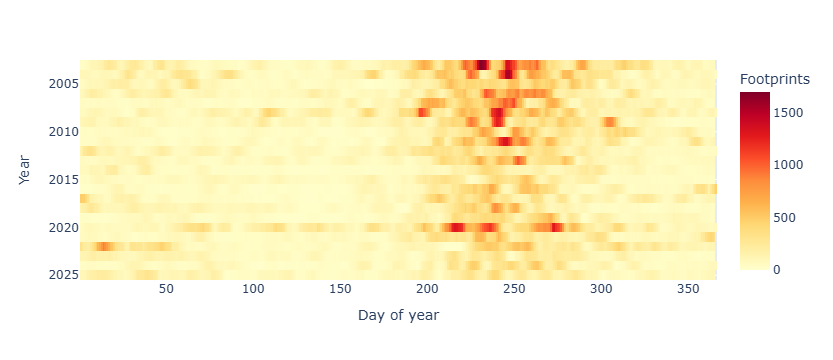

In [32]:
import plotly.express as px

s = daily.loc['2003-01-01':'2025-12-31'] #only taking full years
s = s.rolling(7, center = True, min_periods=1).mean() #smoothing daily noise

tbl = pd.DataFrame({'year': s.index.year, 'doy': s.index.dayofyear, 'value': s.values})
matrix = tbl.pivot(index ='year', columns='doy', values='value')

fig = px.imshow(matrix, aspect='auto', color_continuous_scale='YlorRd', 
               labels=dict(x='Day of year', y='Year', color='Footprints'))
fig.show()

<Axes: title={'center': 'Typical fire activity by day of year'}, xlabel='doy'>

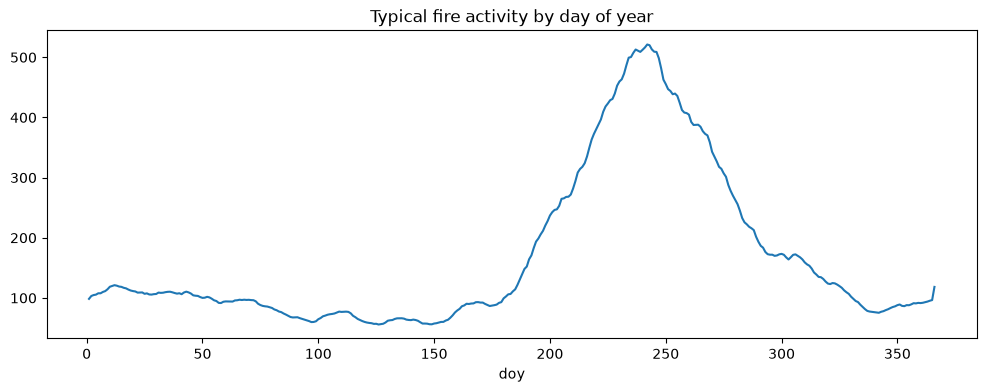

In [33]:
#Checking for each day whether today is abnormal compared to normal years
s = daily.loc['2003-01-01':'2025-12-31'].rolling(15, center=True,min_periods=1).mean()
tbl = pd.DataFrame({'date':s.index, 'year':s.index.year,'doy':s.index.dayofyear,'value':s.values})
baseline = tbl.groupby('doy')['value'].agg(['mean','std'])
baseline['mean'].plot(figsize=(12,4), title='Typical fire activity by day of year')


In [34]:
#Checking how unusual is each day

tbl = tbl.join(baseline, on='doy')
#z says how many typical swings above normal a day is z=0 is normal; z=1 is high; z=2 unusually high
tbl['z'] = (tbl['value']-tbl['mean']) / tbl['std'].replace(0,np.nan) 

unusual = tbl[tbl['z'] > 2]
print(unusual.groupby('year').size())

year
2003     49
2004     39
2005      4
2006     11
2007      8
2008     72
2009     18
2010      8
2011     12
2016     15
2017      6
2020    129
2021     10
2022     71
2025      3
dtype: int64
